# Clustering Evaluation


Confronto tra run di clustering già **prodotte**

Prima si caricano le run scelte da disco (§0), poi si valutano in tre modi:

1. **Confronto visivo** - affianca in una griglia i plot già prodotti (`cluster_plot.png`) di run di produzione scelte a mano.

2. **Metriche intrinseche** - quanto è compatta/separata una singola run:
      - Silhouette,
      - Davies-Bouldin,
      - Calinski-Harabasz
      - il Dunn Index
3. **Metriche di confronto diretto** - quanto si assomigliano due o più run:
      - ARI e NMI
      - una match matrix
      - Subsampling Stability Index


In [53]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics.cluster import contingency_matrix
from scipy import stats 


# Repo root isn't on sys.path when this notebook runs with cwd=notebooks/post-results_analysis/ -
# same fix as temp/*/run_prototype.py, needed here for the `from src...` imports below.
NOTEBOOK_REPO_ROOT = Path.cwd().resolve().parents[1]
if str(NOTEBOOK_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_REPO_ROOT))

from src.analysis.clustering_tuning import compute_clustering_metrics, dunn_index
from src.analysis.consensus_clustering import subsampling_stability_index
from src.utils.artifacts import load_matrix, read_run_params

sns.set_theme(style="whitegrid")


## 0. Loading

Nessun dataset sintetico: carichiamo direttamente run di produzione **reali** già eseguite
(`results/<lesion|sdc>/clustering/production/`).

1. `list_production_runs(object_type, method=None)` elenca le run disponibili leggendo i
   `runs.csv` per-metodo già scritti dalla pipeline. Vanno scelti esplicitamente:
   - `object_type`: `"lesion"` o `"sdc"` (obbligatorio),
   - `method`: es. `"kmeans"`, `"hdbscan"`, ... (opzionale - se omesso elenca tutti i metodi).

2. Si sceglie a mano quali caricare in `SELECTED_RUNS` (nome leggibile -> path `output`),
   copiando i valori dalla tabella.

3. Il loop di caricamento legge ciascuna in un dict `runs` (matrice, metadati, label,
   parametri) - usato sia dal confronto visivo sia dalle metriche.

In [54]:
def list_production_runs(object_type: str, method: str | None = None) -> pd.DataFrame:
    """Run di produzione già eseguite per 'lesion' o 'sdc', lette dai runs.csv per-metodo
    sotto results/<object_type>/clustering/production/<metodo>/runs.csv - solo indicizzate
    per la selezione manuale qui sotto, nessun dato ricalcolato.

    method: se dato, filtra a un solo sottodirectory (es. "kmeans", "hdbscan") invece di
    leggere tutti i metodi disponibili."""
    if object_type not in ("lesion", "sdc"):
        raise ValueError(f"object_type deve essere 'lesion' o 'sdc', ricevuto {object_type!r}")

    production_root = NOTEBOOK_REPO_ROOT / "results" / object_type / "clustering" / "production"
    if not production_root.is_dir():
        raise FileNotFoundError(f"{production_root} non esiste - nessuna run di produzione per {object_type!r}")

    if method is not None:
        runs_csv_paths = [production_root / method / "runs.csv"]
        if not runs_csv_paths[0].is_file():
            available = sorted(p.parent.name for p in production_root.glob("*/runs.csv"))
            raise FileNotFoundError(
                f"{runs_csv_paths[0]} non esiste - metodo {method!r} sconosciuto o senza run di produzione "
                f"per {object_type!r}. Metodi disponibili: {available}"
            )
    else:
        runs_csv_paths = sorted(production_root.glob("*/runs.csv"))

    if not runs_csv_paths:
        print(f"nessun runs.csv sotto {production_root} - nessuna run di produzione ancora eseguita per {object_type!r}")
        return pd.DataFrame()

    per_method = []
    for runs_csv_path in runs_csv_paths:
        method_df = pd.read_csv(runs_csv_path)
        method_df.insert(0, "method", runs_csv_path.parent.name)  # .../production/<metodo>/runs.csv
        per_method.append(method_df)

    # colonne extra per-metodo (es. linkage per agglomerative, affinity per spectral) non allineate
    # tra metodi diversi: pd.concat le riempie a NaN dove non applicabili, va bene per una tabella di browsing
    return pd.concat(per_method, ignore_index=True, sort=False)


Seleziona oggetto di indagine e metodo

In [55]:

found_runs = list_production_runs("lesion", method="kmeans")
# found_runs = list_production_runs("lesion")  # senza filtro: tutti i metodi insieme
display(found_runs)  # esplicito (non l'ultima espressione della cella): così appare PRIMA dei path stampati sotto


,method,session,reduction_method,reduction_n_components,reduction_metric,n_clusters,timestamp,input_path,params,output,notes
0,kmeans,s1.1,umap,2,euclidean,4,01-09-26 00:47,results/lesion/dim_reduction/production/umap/1...,"{""n_clusters"": 4, ""random_state"": 0, ""n_init"":...",results/lesion/clustering/production/kmeans/um...,"scelta post-tuning 27/28-08, vedi clustering_t..."
1,kmeans,s1.1,umap,2,euclidean,5,01-09-26 09:40,results/lesion/dim_reduction/production/umap/1...,"{""n_clusters"": 5, ""random_state"": 0, ""n_init"":...",results/lesion/clustering/production/kmeans/um...,overwrite=true: run riscritto sullo stesso out...
2,kmeans,s1.1,umap,2,euclidean,6,01-09-26 09:41,results/lesion/dim_reduction/production/umap/1...,"{""n_clusters"": 6, ""random_state"": 0, ""n_init"":...",results/lesion/clustering/production/kmeans/um...,overwrite=true: run riscritto sullo stesso out...


In [56]:
# path della colonna 'output' pronti per il copia-incolla in SELECTED_RUNS qui sotto, una riga per run
print("\n".join(f'    "{output_path}",' for output_path in found_runs["output"]))


    "results/lesion/clustering/production/kmeans/umap/01-09_s1.1_m_euclidean_n2_k4",
    "results/lesion/clustering/production/kmeans/umap/01-09_s1.1_m_euclidean_n2_k5",
    "results/lesion/clustering/production/kmeans/umap/01-09_s1.1_m_euclidean_n2_k6",


Selezione d'esempio qui sotto per confrontare le run che ci servono, copiando i path stampati sopra.


In [57]:
# nome leggibile -> colonna 'output' di list_production_runs("lesion") (path relativo alla repo root)
SELECTED_RUNS = {
    "kmeans_k4": "results/lesion/clustering/production/kmeans/umap/01-09_s1.1-vol_m_euclidean_n2_k4",
    "kmeans_k6": "results/lesion/clustering/production/kmeans/umap/01-09_s1.1-vol_m_euclidean_n2_k6",
    "agglomerative_k4": "results/lesion/clustering/production/agglomerative/umap/01-09_s1.1-vol_m_euclidean_n2_k4_link_average",
    "gmm_k4": "results/lesion/clustering/production/gmm/umap/01-09_s1.1-vol_m_euclidean_n2_n_comp4_cov_full",
}

runs = {}
for name, output_dir in SELECTED_RUNS.items():
    input_dir = NOTEBOOK_REPO_ROOT / output_dir
    run_X, run_metadata, _extra_arrays = load_matrix(input_dir)
    method = input_dir.parent.parent.name  # production/<metodo>/<reduction_method>/<run_name>/
    runs[name] = {
        "input_dir": input_dir,
        "method": method,
        "X": run_X,
        "metadata": run_metadata,
        "labels": run_metadata["cluster_label"].to_numpy(),
        "params": read_run_params(input_dir),
    }

for name, run in runs.items():
    print(f"{name} ({run['method']}): {run['X'].shape[0]} soggetti, {len(np.unique(run['labels']))} cluster, params={run['params']}")


kmeans_k4 (kmeans): 1150 soggetti, 4 cluster, params={'n_clusters': 4, 'random_state': 0, 'n_init': 'auto'}
kmeans_k6 (kmeans): 1150 soggetti, 6 cluster, params={'n_clusters': 6, 'random_state': 0, 'n_init': 'auto'}
agglomerative_k4 (agglomerative): 1150 soggetti, 4 cluster, params={'n_clusters': 4, 'linkage': 'average'}
gmm_k4 (gmm): 1150 soggetti, 4 cluster, params={'n_components': 4, 'covariance_type': 'full', 'random_state': 0}


## 1. Plotting

Confronto puramente visivo delle run in `SELECTED_RUNS`

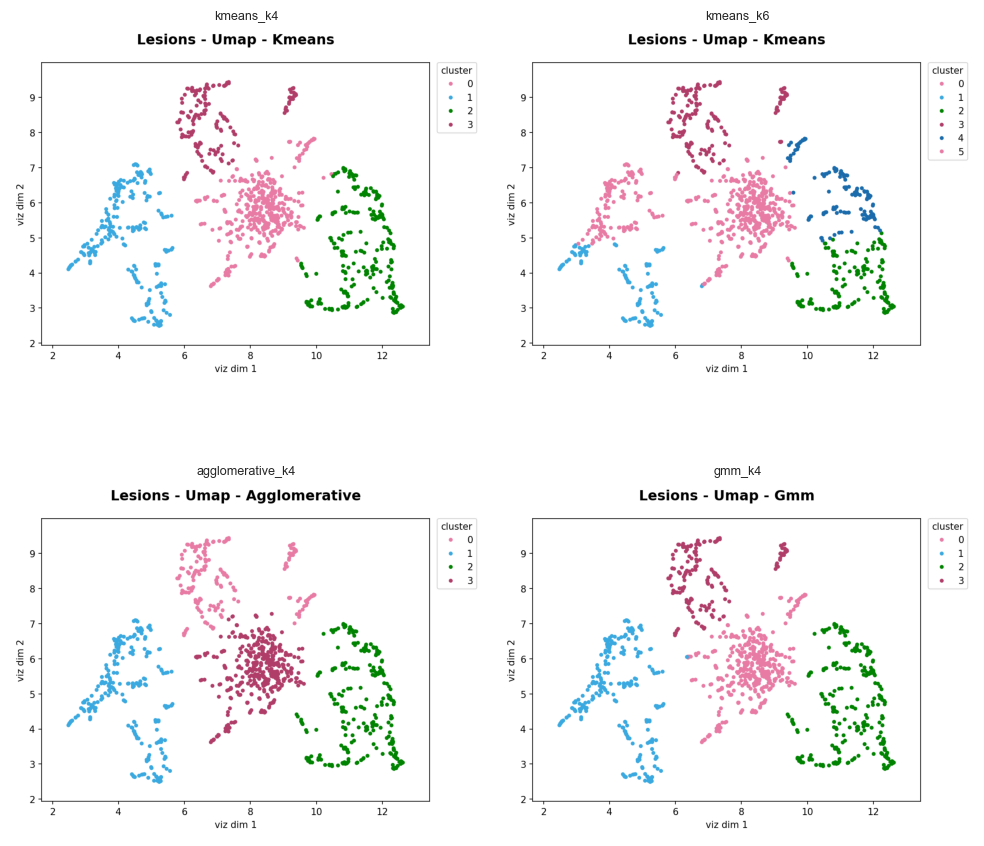

In [58]:
def plot_production_runs(output_dirs: list, plot_file: str = "cluster_plot.png", titles: list | None = None) -> None:
    """Griglia dinamica (quasi quadrata: ceil(sqrt(n)) colonne, ceil(n/colonne) righe) dei
    plot già prodotti in ciascuna output_dir - li carica da disco (plot_file, di default
    cluster_plot.png; passare "silhouette_plot.png" per confrontare quelli), non li ricalcola.

    Esempi di griglia: n=2 -> 1x2, n=3 -> 2x2 (1 vuoto), n=4 -> 2x2, n=5-6 -> 3x2 (con vuoti)."""
    output_dirs = [Path(d) for d in output_dirs]
    if not output_dirs:
        raise ValueError("output_dirs è vuoto - seleziona almeno una run da confrontare")
    if titles is not None and len(titles) != len(output_dirs):
        raise ValueError(f"titles ha {len(titles)} elementi ma output_dirs ne ha {len(output_dirs)}")

    n_runs = len(output_dirs)
    n_cols = int(np.ceil(np.sqrt(n_runs)))
    n_rows = int(np.ceil(n_runs / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows), squeeze=False)
    flat_axes = axes.flatten()

    for i, output_dir in enumerate(output_dirs):
        image_path = output_dir / plot_file
        if not image_path.is_file():
            raise FileNotFoundError(f"{image_path} non esiste - controlla output_dirs/plot_file")
        flat_axes[i].imshow(plt.imread(image_path))
        flat_axes[i].axis("off")
        flat_axes[i].set_title(titles[i] if titles else f"{output_dir.parent.parent.name}/{output_dir.name}", fontsize=9)

    for ax in flat_axes[n_runs:]:  # celle di griglia non usate (es. il 4° slot di una 2x2 con 3 run)
        ax.axis("off")

    fig.tight_layout()


plot_production_runs([run["input_dir"] for run in runs.values()], titles=list(runs.keys()))


## 2. Metriche intrinseche

Una riga per run: 
- Silhouette
- Calinski-Harabasz
- Davies-Bouldin 
- noise_fraction
- Dunn Index. 

In [59]:
intrinsic_rows = []
for name, run in runs.items():
    metrics = compute_clustering_metrics(run["X"], run["labels"])
    metrics["dunn"] = dunn_index(run["X"], run["labels"])
    intrinsic_rows.append({"run": name, **metrics})

intrinsic_table = pd.DataFrame(intrinsic_rows).set_index("run")
intrinsic_table


,silhouette,calinski_harabasz,davies_bouldin,noise_fraction,dunn
run,,,,,
kmeans_k4,0.496778,1552.576348,0.693189,0.0,0.014945
kmeans_k6,0.474556,1520.819913,0.801072,0.0,0.009643
agglomerative_k4,0.491712,1529.045847,0.746909,0.0,0.046905
gmm_k4,0.496008,1549.377925,0.692717,0.0,0.006438


**Lettura**

- **Silhouette** ([-1, 1]): più alto è meglio.

- **Calinski-Harabasz**: più alto è meglio, confrontabile solo tra run sugli stessi dati.
- **Davies-Bouldin** (>= 0): più basso è meglio.
- **Dunn Index** (>= 0): più alto è meglio, sensibile a outlier.
- **noise_fraction** (solo density-based, es. HDBSCAN): quota di punti non assegnati - non
  è "più basso è sempre meglio", può solo indicare parametri troppo permissivi.

Nessuna soglia assoluta di "buono/cattivo": senza ground truth vanno lette in relativo -
stesso metodo a `k` diversi (migliora o degrada?), metodi diversi allo stesso `k`
(convergono?). AIC/BIC (specifici di GMM) non sono qui.

## 3. Metriche di confronto diretto: ARI / NMI

Calcoliamo 
- Adjusted Rand Index
- Normalized Mutual Information 

tra ogni coppia di run.

Prima di confrontare due run verifichiamo esplicitamente che condividano lo stesso ordine di `subject_id`: run che coprissero soggetti diversi andrebbero allineate (es. un merge su `subject_id`) prima di confrontare le label posizionalmente.

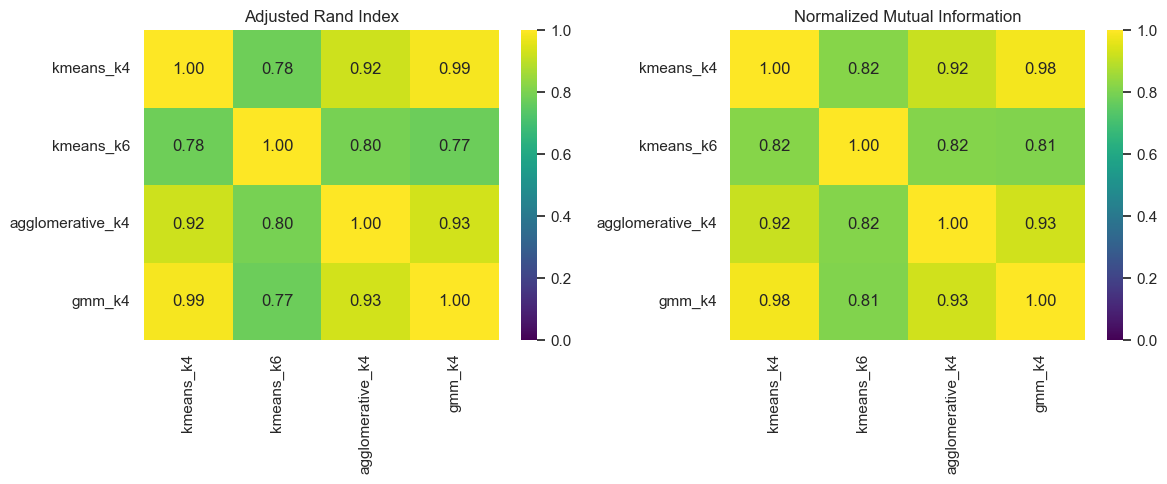

In [60]:
def aligned_labels(name_a: str, name_b: str) -> tuple[np.ndarray, np.ndarray]:
    subjects_a = runs[name_a]["metadata"]["subject_id"]
    subjects_b = runs[name_b]["metadata"]["subject_id"]
    if not subjects_a.equals(subjects_b):
        raise ValueError(
            f"{name_a!r} and {name_b!r} don't share the exact same subject_id order - align "
            "them explicitly (e.g. a merge on subject_id) before comparing labels positionally"
        )
    return runs[name_a]["labels"], runs[name_b]["labels"]


run_names = list(runs.keys())
ari_table = pd.DataFrame(index=run_names, columns=run_names, dtype=float)
nmi_table = pd.DataFrame(index=run_names, columns=run_names, dtype=float)
for name_a in run_names:
    for name_b in run_names:
        labels_a, labels_b = aligned_labels(name_a, name_b)
        ari_table.loc[name_a, name_b] = adjusted_rand_score(labels_a, labels_b)
        nmi_table.loc[name_a, name_b] = normalized_mutual_info_score(labels_a, labels_b)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(ari_table, annot=True, fmt=".2f", vmin=0, vmax=1, cmap="viridis", ax=axes[0])
axes[0].set_title("Adjusted Rand Index")
sns.heatmap(nmi_table, annot=True, fmt=".2f", vmin=0, vmax=1, cmap="viridis", ax=axes[1])
axes[1].set_title("Normalized Mutual Information")
fig.tight_layout()


## 4. Match matrix tra una coppia di run

Una coppia allo stesso `k` ma metodo diverso è la più interessante da ispezionare a occhio: un eventuale disaccordo non si spiega con un `k` sovra o sotto-specificato, ma riflette un vero disaccordo tra criteri di raggruppamento.


**Cosa calcola**: 
`contingency_matrix(labels_a, labels_b)` conta, per ogni coppia (cluster di `name_a`, cluster di `name_b`), quanti soggetti cadono in entrambi. Non è un confronto diretto tra etichette - il cluster "0" di un metodo non è "lo stesso" cluster "0" dell'altro, le label sono indipendenti - è pura sovrapposizione punto per punto.

**Come si legge**: se una riga (o colonna) ha la massa concentrata in una sola cella, i due metodi concordano su quel gruppo di soggetti. Se la massa è sparsa su più celle, c'è disaccordo - quel gruppo viene diviso o unito diversamente dai due criteri di clustering.

In [61]:
name_a, name_b = "kmeans_k4", "agglomerative_k4"
labels_a, labels_b = aligned_labels(name_a, name_b)
match_matrix = contingency_matrix(labels_a, labels_b)
match_df = pd.DataFrame(
    match_matrix,
    index=[f"{name_a}={c}" for c in sorted(np.unique(labels_a))],
    columns=[f"{name_b}={c}" for c in sorted(np.unique(labels_b))],
)


match_df


,agglomerative_k4=0,agglomerative_k4=1,agglomerative_k4=2,agglomerative_k4=3
kmeans_k4=0,27,0,4,405
kmeans_k4=1,0,264,0,0
kmeans_k4=2,0,0,285,0
kmeans_k4=3,162,0,0,3


## 5. Subsampling Stability Index

Un clustering può sembrare buono sul 100% dei dati ma dipendere in realtà da un piccolo sottoinsieme di soggetti (outlier, casi limite) - togliere anche solo il 20% dei soggetti non dovrebbe stravolgere la partizione, se la struttura trovata è reale.

**Cosa calcola**: rifittiamo una run con gli stessi parametri su un campione all'80% dei soggetti, poi calcoliamo l'ARI tra questo fit e quello sul 100% dei dati, ristretto agli stessi soggetti, un confronto singolo, non un ensemble di ripetizioni

**Come si legge**: un indice vicino a 1 = la partizione non dipende dal sottoinsieme esatto di soggetti usato, è stabile. 
Un valore basso = togliere quel 20% cambia sostanzialmente i cluster - è un segnale da approfondire prima di fidarsi della run, non un motivo per scartarla automaticamente.

In [62]:
stability_rows = []
for name in ["kmeans_k4", "agglomerative_k4"]:
    run = runs[name]
    index = subsampling_stability_index(run["method"], run["X"], run["params"], subsample_fraction=0.8)
    stability_rows.append({"run": name, "subsampling_stability_index": index})

pd.DataFrame(stability_rows).set_index("run")


,subsampling_stability_index
run,
kmeans_k4,0.937012
agglomerative_k4,0.947951


## 6. Demografiche per cluster

In [63]:
# dataset -> file '_lesions.tsv' in assets/metadata/ (solo le varianti '_lesions', coerenti con
# l'object_type 'lesion' di questo notebook - WashU ha anche '_features'/'_join', stesso schema,
# scartate per non contare gli stessi soggetti 3 volte)
DEMOGRAPHIC_FILES = {
    "UCL-UK": "UCL-UK_UCLStrokeData_participants_lesions.tsv",
    "UKLFR": "UKLFR_stroke_UKLFR_participants_lesions.tsv",
    "PASPORT": "UNIPD_PASPORT_participants_lesions.tsv",
    "PSP": "UNIPD_PSP_participants_lesions.tsv",
    "WashU": "UNIPD_WashU_participants_lesions.tsv",
}

# colonna NIHSS "al baseline" da usare per dataset - gli schemi non sono uniformi:
# UCL-UK non registra NIHSS affatto (None), PASPORT non ha una colonna 'NIHSS' semplice e
# usa 'NIHSS_at_presentation' come proprio baseline; gli altri hanno 'NIHSS' diretto
NIHSS_COLUMN_BY_DATASET = {
    "UCL-UK": None,
    "UKLFR": "NIHSS",
    "PASPORT": "NIHSS_at_presentation",
    "PSP": "NIHSS",
    "WashU": "NIHSS",
}


def load_demographics() -> pd.DataFrame:
    """Età/sesso/NIHSS unificati dai tsv per-dataset di assets/metadata/, indicizzati per
    participant_id (== subject_id di metadata.csv).

    Solleva se lo stesso participant_id compare in più di un tsv: con id con prefisso di
    sito (sub-STUCLUKxxxx, sub-STUKLFRxxxx, ...) non dovrebbe mai succedere - un duplicato
    indicherebbe un problema nei dati sorgente, non va nascosto con un dedupe silenzioso."""
    tables = []
    for dataset_name, filename in DEMOGRAPHIC_FILES.items():
        raw = pd.read_csv(NOTEBOOK_REPO_ROOT / "assets" / "metadata" / filename, sep="\t")
        nihss_column = NIHSS_COLUMN_BY_DATASET[dataset_name]
        tables.append(pd.DataFrame({
            "participant_id": raw["participant_id"],
            "age": raw["age"],
            "sex": raw["sex"],
            # NaN esplicito dove il dataset non ha NIHSS, non 0 e non stimato
            "NIHSS": raw[nihss_column] if nihss_column is not None else np.nan,
            "dataset": dataset_name,
        }))

    demographics = pd.concat(tables, ignore_index=True)

    # controllo esplicito invece di un dedupe silenzioso (lessons_learned #5) - se scatta,
    # è un segnale di un problema nei tsv sorgente da investigare, non da nascondere
    duplicated_ids = sorted(demographics.loc[demographics["participant_id"].duplicated(keep=False), "participant_id"].unique())
    if duplicated_ids:
        raise ValueError(f"participant_id duplicati tra i tsv di assets/metadata/: {duplicated_ids}")

    return demographics.set_index("participant_id")



In [64]:

DEMOGRAPHICS = load_demographics()
DEMOGRAPHICS

,age,sex,NIHSS,dataset
participant_id,,,,
sub-STUCLUK0001,NaN,NaN,NaN,UCL-UK
sub-STUCLUK0002,83.0,M,NaN,UCL-UK
sub-STUCLUK0003,NaN,NaN,NaN,UCL-UK
sub-STUCLUK0004,81.0,F,NaN,UCL-UK
sub-STUCLUK0005,84.0,M,NaN,UCL-UK
...,...,...,...,...
sub-STUNIPD0247,65.0,M,1.0,WashU
sub-STUNIPD0248,57.0,M,16.0,WashU
sub-STUNIPD0249,58.0,F,NaN,WashU


In [65]:
run_name = "kmeans_k4"  # una delle chiavi di SELECTED_RUNS/runs (§0) - cambia qui per ispezionare un'altra run

# left join: ogni soggetto della run mantiene la sua riga anche se manca nelle demografiche
# (indicator=True aggiunge la colonna '_merge' per distinguere i due casi esplicitamente)
run_demographics = runs[run_name]["metadata"][["subject_id", "cluster_label"]].merge(
    DEMOGRAPHICS, left_on="subject_id", right_index=True, how="left", indicator=True
)

# soggetti della run senza corrispondenza in assets/metadata/ - segnalati, non lasciati
# scomparire in silenzio dentro le statistiche successive come NaN qualunque
unmatched = run_demographics.loc[run_demographics["_merge"] == "left_only", "subject_id"]
if not unmatched.empty:
    print(f"{len(unmatched)}/{len(run_demographics)} soggetti di {run_name!r} senza demografiche in assets/metadata/: {unmatched.tolist()}")
run_demographics = run_demographics.drop(columns="_merge")

# una riga per cluster: numerosità, età/NIHSS medi ± std, quota maschi (%)
cluster_demographics = run_demographics.groupby("cluster_label").agg(
    n=("subject_id", "count"),
    age_mean=("age", "mean"),
    age_std=("age", "std"),
    NIHSS_mean=("NIHSS", "mean"),
    NIHSS_std=("NIHSS", "std"),
    pct_male=("sex", lambda s: (s == "M").mean() * 100),
)
cluster_demographics


,n,age_mean,age_std,NIHSS_mean,NIHSS_std,pct_male
cluster_label,,,,,,
0,436,65.262673,14.647518,3.296758,4.177226,59.174312
1,264,64.500000,14.756971,7.524194,6.526760,54.166667
2,285,65.656140,13.482422,6.536232,5.857284,50.526316
3,165,65.769697,14.120831,4.807692,4.772387,63.030303


In [66]:

def kruskal_by_cluster(df: pd.DataFrame, value_column: str) -> tuple[float, float]:
    """Kruskal-Wallis (non parametrico, non assume normalità) di value_column tra i gruppi
    di cluster_label - righe NaN su value_column escluse dal test, non convertite in 0."""
    groups = [group[value_column].dropna().to_numpy() for _, group in df.groupby("cluster_label")]
    groups = [g for g in groups if len(g) > 0]  # scarta cluster rimasti senza dati validi su questa variabile
    if len(groups) < 2:
        raise ValueError(f"servono almeno 2 cluster non vuoti su {value_column!r} per il test, trovati {len(groups)}")
    return stats.kruskal(*groups)


# H0: la variabile ha la stessa distribuzione in tutti i cluster - p basso la rigetta
age_stat, age_p = kruskal_by_cluster(run_demographics, "age")
nihss_stat, nihss_p = kruskal_by_cluster(run_demographics, "NIHSS")

# per una variabile categorica (sex) serve un test diverso: chi-quadro sulla tabella di contingenza
sex_crosstab = pd.crosstab(run_demographics["cluster_label"], run_demographics["sex"])
sex_chi2, sex_p, _dof, _expected = stats.chi2_contingency(sex_crosstab)

# p < 0.05 = quella variabile non è distribuita uniformemente sui cluster trovati - non prova
# che il clustering sia "corretto", solo che intercetta qualcosa di non casuale su quella variabile
pd.DataFrame({
    "test": ["Kruskal-Wallis (age)", "Kruskal-Wallis (NIHSS)", "Chi-quadro (sex)"],
    "statistic": [age_stat, nihss_stat, sex_chi2],
    "p_value": [age_p, nihss_p, sex_p],
}).set_index("test")

,statistic,p_value
test,,
Kruskal-Wallis (age),0.636322,8.880693e-01
Kruskal-Wallis (NIHSS),118.911475,1.323916e-25
Chi-quadro (sex),8.792440,3.218167e-02
